<a href="https://colab.research.google.com/github/Luke-687/Simulating-Chemotaxis--Q-learning-and-Heuristic-/blob/main/Heuristic%20Approach/Model-Data-and-Visuals/Avg-Dist-and-Steps-Inside-Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import matplotlib.pyplot as plt

In [ ]:
#s is for the steepness of the gradient
def defineScene(xS,yS, s):
  x = []
  y = []
  color = []
  gradient = []
  reward = []
  #Consider 20x20 grid, source of chemical at (15,15) with a decrease in alpha by r^2
  for i in range (0,xS+1):
    for j in range (0,yS+1):
      x.append(j)
      y.append(i)
      #distance based calculations:
      distance = math.sqrt((i-(xS/2))**2+(j-(yS/2))**2)
      if(distance <= 5):
        color.append("green")
        if(not distance<=1):
          gradient.append(1/(distance**s))
          reward.append(10/(distance**s))
        else:
          gradient.append(1)
          reward.append(50)
      else:
        color.append("green")
        gradient.append(0)
        reward.append(-50)
  return x, y, gradient, reward

def calculate_velocity(posX, posY, rewards):
  posX = int(posX)
  posY = int(posY)
  currentReward = rewards[posX+posY*20]
  if(currentReward<0):
    velocity = 4
  else:
    velocity = 1.5/currentReward
  if(velocity>=4):
    velocity = 4
  if(velocity<=1):
    velocity = 1
  return velocity

def calculate_direction(currentX, currentY, pastR, currentR, currentDirection, p):

  #Define the basic change in the direction
  change=0
  currentPos = math.sqrt((currentX-9.5)**2 + (currentY-9.5)**2)

  if(not currentR==0 and not pastR==0):

    if(currentPos<=5):

      change = 360*(abs(pastR/currentR)**0.8)*((random.choice([-1,1])))
      # print("Inside: " + str(change))

    else:

      if(pastR>currentR):

        if(abs(pastR)<abs(currentR)):
          change = (180-180*(abs((pastR)/(currentR))**p))*((random.choice([-1,1,-1,-1,-1])))
          # print("Outside: " + str(change))

        else:
          change = (180-180*(abs((currentR)/(pastR))**p))*((random.choice([-1,1,-1,-1,-1])))
          # print("Outside: " + str(change))


  newDirection = (currentDirection+change)%360
  return (newDirection)

def simulate (alpha, gamma, xS, yS,steps, steep):
  #Define the initial parameters
  velocity = 4
  direction = random.randint(10,80)
  #Starting position is some (x,y) outside of gradient
  currentX = 0
  currentY = 0
  stepsToBeMade=steps
  xG, yG, gradient, reward = defineScene(xS, yS, steep)
  #This works as an adjustment to the direction recalculation
  p=0.59
  #This works as an adjustment to the alpha and gamma in updated rewards
  mult = 3.75

  #Track x,y pos
  x=[]
  y=[]

  pastReward = 0
  for i in range(0, stepsToBeMade):
    #Enter and calculate reward of values which are about to be moved on from
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    x.append(currentX)
    y.append(currentY)

    #Find new position, and new current reward
    brownian = brownianMotion()
    changeX = velocity * math.cos(direction*math.pi/180) + brownian[0]
    changeY = velocity * math.sin(direction*math.pi/180) + brownian[1]
    currentX = x[-1] + changeX
    currentY = y[-1] + changeY
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    currentReward = pastReward + mult*alpha*(reward[int(currentX+currentY*20)]+mult*gamma*(reward[int(currentX+currentY*20)]-pastReward))

    #Redifine velocity and direction for next steps
    velocity = calculate_velocity(int(currentX), int(currentY), reward)
    direction = calculate_direction(currentX, currentY, pastReward, currentReward, direction, p)
    pastReward = currentReward
  return x,y

def brownianMotion():
  result = [0,0]
  xChange = random.random()/4
  yChange = random.random()/4
  for i in range(10):
    xChange+= random.random()/100 * (-1**(random.randint(1,2)))
    yChange+= random.random()/100 * (-1**(random.randint(1,2)))
  result = [xChange, yChange]
  return result

In [ ]:
#Must record average distance from center, average step to reach center, and error bars recorded as points

#Later analysis
forLaterAnalysis = [] #this will hold information in the format [alpha, gamma, finalDistFromCenter, avgStepsInCenter]

for alpha in range(0,11): #define the alpha values here such that it ranges form 0-1
  for gamma in range(0,11): #define the gamma values here such that it ranges from 0-1

    alphaRun = alpha/10
    gammaRun = gamma/10

    #consider all data collection points in a single 1000 simulation run at a certain alpha and gamma value
    errorBarsX = []
    errorBarsY = []
    avgDist = []
    steps = []
    for i in range(30):
      avgDist.append(0)
      steps.append(i)

    #This is for later analysis
    finalDistFromCenter = 0
    avgStepsInCenter = 0

    for runs in range(1000):
      #Get the x,y positions the agent reaches when modeled on given alpha and gamma values
      xRun, yRun = simulate(alphaRun, gammaRun, 19,19,30,0.75)
      for step in range(len(xRun)):
        fromCenter = math.sqrt((xRun[step]-9.5)**2+(yRun[step]-9.5)**2)
        if(random.random()<0.1):
          errorBarsX.append(step)
          errorBarsY.append(fromCenter)
        avgDist[step] += fromCenter/1000
        if(fromCenter<=5):
          avgStepsInCenter+=1/30000
        if(step==len(xRun)-1):
          finalDistFromCenter+=fromCenter/1000

    #Take the data collected and record or visualize
    forLaterAnalysis.append([alphaRun, gammaRun, finalDistFromCenter, avgStepsInCenter])

    # plt.figure(figsize=(5, 5))
    # plt.plot(steps, avgDist, color = 'black')
    # plt.scatter(errorBarsX, errorBarsY, alpha = 0.2, color = 'orange')
    # plt.xlabel('Steps')
    # plt.ylabel('Distance From Center (Average)')
    # plt.title('Alpha: ' + str(alphaRun) + " Gamma: " + str(gammaRun))

[13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 13.4350288425442, 12.456229442084572, 12.40521158887954, 11.270545093791219, 11.55919381956692, 11.339304831142531, 11.550195470512795, 11.65846905238326, 11.75040226552129, 11.406403930213353, 11.093604730025008, 10.739830380638054, 12.512121524744098, 11.067842328378914, 11.470147849683924, 11.403479701264269, 11.532350004224647, 10.557425907456562, 8.472708547378476, 6.775795310450633, 11.227834863958632, 8.255776453916498, 5.4713221561661, 12.414124887524965, 11.312775722495072, 11.731631062920492, 11.259915718167427, 8.513030499398997, 10.725660878696438, 8.042611694462419, 4.857326618122396, 3.729732546112165, 3.2177346801096594, 3.037537406277861, 12.488643687190823, 11.36740807927972, 11.394182843392308, 8.337943111561742, 11.214550984343717, 5.698554380728659, 3.7620016023503497, 3.1626349206867412,

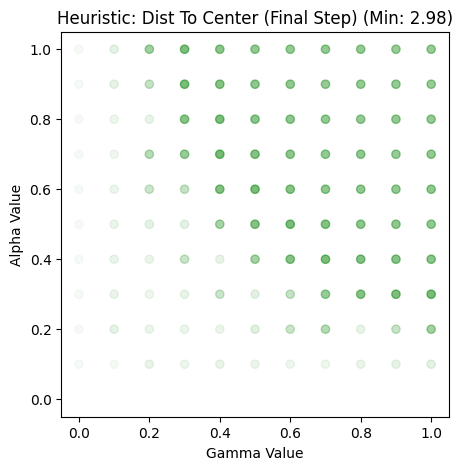

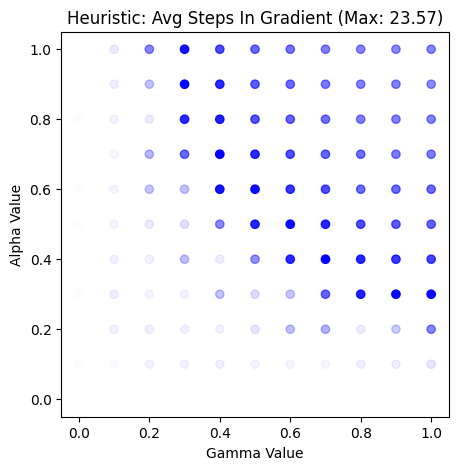

In [ ]:
gammaX = []
alphaY = []
finalDist = []
avgIn = []
for data in range(len(forLaterAnalysis)):
  gammaX.append(forLaterAnalysis[data][1])
  alphaY.append(forLaterAnalysis[data][0])
  finalDist.append(forLaterAnalysis[data][2])
  avgIn.append(forLaterAnalysis[data][3])
print(finalDist)

maxDist = max(finalDist)
minDist = float(min(finalDist))
maxDist = float(maxDist)
maxIn = max(avgIn)
maxIn = float(maxIn)
for val in range(len(finalDist)): #same as length of avgIn so use length final distance for both
  finalDist[val]=1-(float(finalDist[val])/maxDist)**0.5
  avgIn[val]=(avgIn[val]/(maxIn))**3

#Graph the results in order to compare the effectiveness of models, such that the darker the color of the data point, the better the model performance
plt.figure(figsize=(5, 5))
plt.xlabel("Gamma Value")
plt.ylabel("Alpha Value")
plt.title("Heuristic: Dist To Center (Final Step) (Min: "+ str(round(minDist,2)) + ")")
plt.scatter(gammaX, alphaY, alpha = finalDist, color = "green")

plt.figure(figsize=(5, 5))
plt.xlabel("Gamma Value")
plt.ylabel("Alpha Value")
plt.title("Heuristic: Avg Steps In Gradient (Max: " + str(round(maxIn*30,2)) + ")")
plt.scatter(gammaX, alphaY, alpha = avgIn, color = 'blue')